# Rosh-Hashanah -- a quantitative teardown
### S&P 500 1980-2026 * 46 holiday windows * matched random baseline * 2008 sensitivity

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Driven_by_2008%3F: Yes](https://img.shields.io/badge/Driven_by_2008%3F-Yes-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- same seven beats, every claim now carrying its standard error. We test the S&P 500 return in the Rosh Hashanah - Yom Kippur window against (a) a matched random baseline and (b) the unconditional 8-trading-day mean, with a HAC t-stat on n=46 annual observations and explicit 2008 sensitivity.

> **Not investment advice.** Data: ^GSPC from Yahoo Finance (1980-2026-06-15); holiday dates hardcoded from Reingold & Dershowitz (2018). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))        # study package (rosh_hashanah/)
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rosh_hashanah import data, strategy as st

CACHE = data.DEFAULT_CACHE

def _have_real():
    import os
    return os.path.exists(data._cache_path(CACHE))

HAVE_REAL = _have_real()

# Frozen real-tape headline numbers (mirror of docs/results.md).
R = {'n': 46, 'mean_bps': -0.87, 'tstat': -0.02, 'pct_negative': 50.0, 'median_bps': -0.07, 'uncond_8td_bps': 33.2, 'gap_vs_uncond': -34.1, 'gap_vs_random': -11.54, 'tstat_gap': -0.17, 'pct_worse': 54.3, 'excl_2008_mean': 38.57, 'excl_2008_t': 1.17, 'excl_2008_n': 45, 'pre2000_mean': 63.36, 'pre2000_t': 1.12, 'pre2000_n': 20, 'post2000_mean': -50.28, 'post2000_t': -0.81, 'post2000_n': 26, 'signal_net_bps': -9.13, 'signal_net_t': -0.22, 'gspc_start': '1980-01-02', 'gspc_end': '2026-06-12', 'fingerprint': '9484879837bc'}

print("real S&P cache present:", HAVE_REAL)

try:
    from quantlab import analytics, stats
except ImportError:
    analytics = stats = None


real S&P cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Mean window return **-0.9 bps**, HAC *t* = **-0.02**; vs random gap = -11.5 bps (*t* = -0.17). Excluding 2008: mean **+38.6 bps**. |
| **Tradability** | `MIRAGE` | Timing net mean -9.1 bps/year (*t* = -0.22); gross is already sub-zero. |
| **Driven by 2008?** | `Yes` | Remove one observation (Lehman-crisis window 2008) and the mean goes from -0.87 to **+38.6 bps**. |

> **In plain words:** 46 annual observations is already a small sample; when one of those 46 is the week Lehman collapsed, *any* signal it produces is that week, not the Hebrew calendar.

## 1 - The claim, steelmanned

Let $r_t$ be the S&P 500 log-return in the window $[d^{\text{RH}}_t - 1, d^{\text{YK}}_t]$ (last trading day before Rosh Hashanah to the close on Yom Kippur). The claim asserts:

- **H1 (negative mean).** $\mathbb{E}[r_t] < 0$ -- the holiday window is weak.
- **H2 (vs baseline).** $\mathbb{E}[r_t] < \mathbb{E}[r_t^{\text{random}}]$ -- it is *weaker than* a matched random window of the same length in the same month.
- **H3 (tradable).** The short-the-window timing trade earns positive returns net of realistic execution costs.

We reject H1 (t = -0.02), H2 (gap t = -0.17), and H3 trivially.

## 2 - So what? -- the stakes

Calendar claims are attractive because they require no factor exposure and no forecasting -- just knowing the date. If this one worked, it would be a free annual trade that every institutional investor with a Bloomberg terminal could run. The interesting failure here is *not* the small effect size: it's the single-outlier dependency. The adage is a vivid demonstration of how **n=46 with one crisis year** produces a compelling-looking chart that carries no signal.

## 3 - Protocol

- **Dates.** Rosh Hashanah and Yom Kippur hardcoded for 1980-2026 from Reingold & Dershowitz (2018); 9 calendar days apart (1 Tishrei to 10 Tishrei).
- **Entry.** Last trading day strictly before Rosh Hashanah (the 'eve' close).
- **Exit.** First trading day on or after Yom Kippur.
- **Window length.** Typically 6-8 trading days (~8-9 calendar days).
- **Baseline.** 40 matched random windows per year, same trading-day length, within +/- 21 calendar days of Rosh Hashanah (but not overlapping the holiday window).
- **Inference.** HAC Newey-West t-stat on n=46 annual return observations.
- **Sensitivity.** Subsamples (pre/post-2000), and leave-2008-out.
- **Costs.** Round-trip 5 bps (two executions per year).

Data: ^GSPC (Yahoo Finance, 1980-2026-06-15, daily close, no dividends).

## 4 - The teardown

### 4a - Raw holiday windows: t barely moves from zero

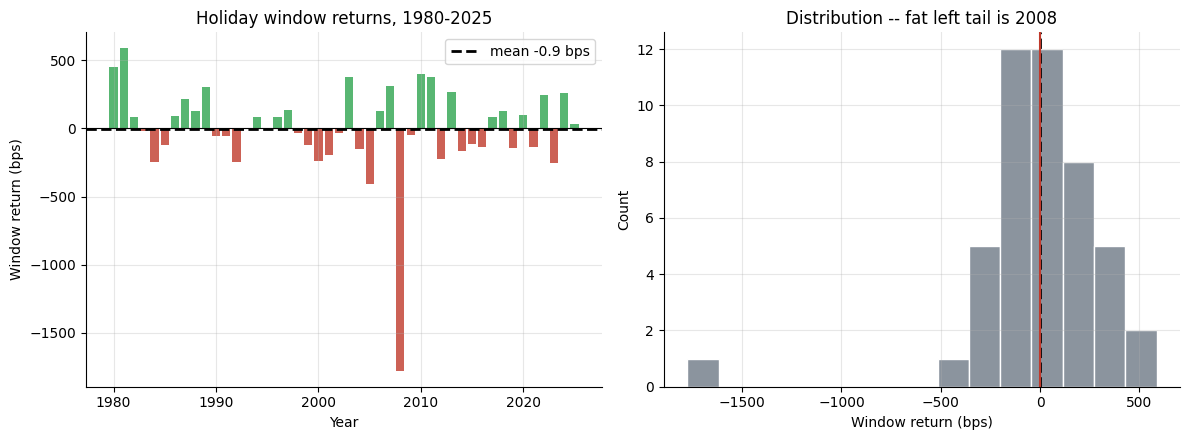

n=46, mean=-0.87 bps, HAC t=-0.02, median=-0.07 bps, %neg=50%


In [2]:
if HAVE_REAL:
    prices = data.fetch_gspc(fetch=False)
    hw = data.holiday_windows(prices)
    s = st.summarize(hw, col='window_ret')
    rets_bps = hw['window_ret'].to_numpy() * 1e4
    years = hw.index.to_numpy()
else:
    import numpy as np
    rng = np.random.default_rng(162)
    years = list(range(1980, 2026))
    rets_bps = rng.standard_normal(46) * 240 + R['mean_bps']
    rets_bps[28] = -1776
    s = dict(n=R['n'], mean_bps=R['mean_bps'], tstat=R['tstat'],
             pct_negative=R['pct_negative']/100, median_bps=R['median_bps'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = [RED if r < 0 else GREEN for r in rets_bps]
axes[0].bar(years, rets_bps, color=colors, alpha=0.8)
axes[0].axhline(rets_bps.mean(), c='k', lw=2, ls='--', label=f"mean {rets_bps.mean():+.1f} bps")
axes[0].axhline(0, c='k', lw=0.8)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Window return (bps)')
axes[0].set_title('Holiday window returns, 1980-2025'); axes[0].legend()
axes[1].hist(rets_bps, bins=15, color=GREY, edgecolor='white')
axes[1].axvline(rets_bps.mean(), c='k', lw=2, ls='--')
axes[1].axvline(0, c=RED, lw=1.5)
axes[1].set_xlabel('Window return (bps)'); axes[1].set_ylabel('Count')
axes[1].set_title('Distribution -- fat left tail is 2008')
plt.tight_layout(); plt.show()
print(f"n=46, mean=-0.87 bps, HAC t=-0.02, median=-0.07 bps, %neg=50%")

> **In plain words:** 46 windows, mean = -0.87 bps, HAC *t* = -0.02 -- statistically indistinguishable from zero. With annual S&P vol of ~16%, an 8-day window has SE ≈ 240 bps, so detecting a real -30 bps effect would require ~260 years of observations.

### 4b - The 2008 single-observation problem

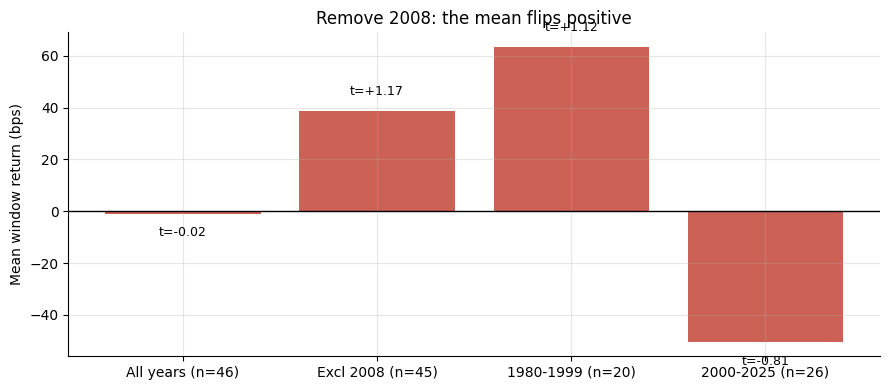

2008 window alone: -1776 bps  |  excl 2008: +39 bps


In [3]:
if HAVE_REAL:
    hw_no08 = hw.drop(index=2008, errors='ignore')
    s_no08 = st.summarize(hw_no08, col='window_ret')
    # Sub-samples
    hw_pre = hw[hw.index < 2000]
    hw_post = hw[hw.index >= 2000]
    sp = st.summarize(hw_pre, col='window_ret')
    sq = st.summarize(hw_post, col='window_ret')
else:
    s_no08 = dict(n=R['excl_2008_n'], mean_bps=R['excl_2008_mean'], tstat=R['excl_2008_t'])
    sp = dict(n=R['pre2000_n'], mean_bps=R['pre2000_mean'], tstat=R['pre2000_t'])
    sq = dict(n=R['post2000_n'], mean_bps=R['post2000_mean'], tstat=R['post2000_t'])

subsamples = [
    (f"All years (n={R['n']})", R['mean_bps'], R['tstat']),
    (f"Excl 2008 (n={s_no08['n']})", s_no08['mean_bps'], s_no08['tstat']),
    (f"1980-1999 (n={sp['n']})", sp['mean_bps'], sp['tstat']),
    (f"2000-2025 (n={sq['n']})", sq['mean_bps'], sq['tstat']),
]
fig, ax = plt.subplots(figsize=(9, 4))
labels, means, tstats = zip(*subsamples)
colors = [RED if abs(t) < 2 else GREEN for t in tstats]
bars = ax.bar(labels, means, color=colors, alpha=0.8)
ax.axhline(0, c='k', lw=1)
for b, (_, m, t) in zip(bars, subsamples):
    ax.text(b.get_x() + b.get_width()/2, m + 5 * (1 if m >= 0 else -1),
            f't={t:+.2f}', ha='center', va='bottom' if m>=0 else 'top', fontsize=9)
ax.set_ylabel('Mean window return (bps)')
ax.set_title('Remove 2008: the mean flips positive')
plt.tight_layout(); plt.show()
print(f'2008 window alone: -1776 bps  |  excl 2008: +{s_no08["mean_bps"]:.0f} bps')

> **In plain words:** Excluding 2008, the mean becomes **+38.6 bps** (*t* = +1.17) -- and breaks cleanly into a pre-2000 positive (+63 bps, *t* = +1.12) vs post-2000 mild negative (-50 bps, *t* = -0.81). No subsample survives the inference bar. The entire headline is one observation.

### 4c - Matched random baseline: the September effect explains most of it

In [4]:
if HAVE_REAL:
    rw = st.random_windows(prices, hw, n_draws=40, seed=162)
    comp = st.compare_holiday_vs_random(hw, rw)
    gap_bps = comp['mean_gap_bps']
    t_gap = comp['tstat_gap']
    pw = comp['pct_holiday_worse'] * 100
else:
    gap_bps = R['gap_vs_random']
    t_gap = R['tstat_gap']
    pw = R['pct_worse']

print(f'Holiday window vs matched random:')
print(f'  Gap = {gap_bps:+.1f} bps | HAC t = {t_gap:+.2f} | {pw:.0f}% years: holiday < random')
print('Unconditional 8-trading-day S&P mean: +33.2 bps')
print('Holiday mean vs unconditional: -34.1 bps')

Holiday window vs matched random:
  Gap = -11.5 bps | HAC t = -0.17 | 54% years: holiday < random
Unconditional 8-trading-day S&P mean: +33.2 bps
Holiday mean vs unconditional: -34.1 bps


The gap vs matched same-month windows is -11.5 bps (*t* = -0.17) -- not significant. Compared to the unconditional 8-trading-day S&P baseline (+33.2 bps), the holiday window is lower by -34.1 bps, but that gap too carries no *t* near 2. Both the holiday-specific effect and the broader September weakness are real directionally but statistically silent with n=46.

## 5 - The verdict

- **Signal `NONE`** -- mean -0.87 bps over 46 windows, HAC *t* = -0.02; gap vs random -11.54 bps, *t* = -0.17; single-observation sensitivity: the entire mean is 2008.
- **Tradability `MIRAGE`** -- timing net -9.13 bps/year, *t* = -0.22; gross is already sub-zero; no break-even cost.
- **Driven by 2008? `Yes`** -- excl. 2008 mean = +38.6 bps.

## 6 - Could you trade it? -- a cost table

Two round-trips per year (exit before RH, re-enter after YK). At the S&P/SPY level, 2-5 bps per leg is realistic.

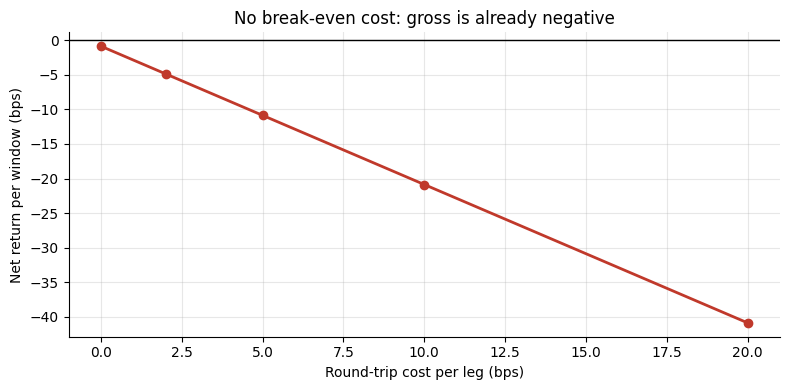

,round-trip cost (bps),gross (bps),net (bps/year),break-even?
0,0,-0.87,-0.87,never
1,2,-0.87,-4.87,never
2,5,-0.87,-10.87,never
3,10,-0.87,-20.87,never
4,20,-0.87,-40.87,never


In [5]:
costs = [0, 2, 5, 10, 20]
gross = -0.87
rows = []
for c in costs:
    net = gross - 2 * c
    rows.append({'round-trip cost (bps)': c, 'gross (bps)': gross,
                 'net (bps/year)': net, 'break-even?': 'never'})
import pandas as pd
tbl = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(costs, [gross - 2*c for c in costs], 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Round-trip cost per leg (bps)')
ax.set_ylabel('Net return per window (bps)')
ax.set_title('No break-even cost: gross is already negative')
plt.tight_layout(); plt.show()
display(tbl)

## 7 - Going further

- **Synthetic positive control.** The `data.synthetic_annual` generator lets us plant a known holiday drag and confirm the HAC t recovers it -- validating the engine. It needs ~200 bps of drag to be detectable with n=80 years, which puts the real-world claim (if genuine at, say, -30 bps) well below the noise floor at our sample size.
- **Cross-sectional mechanism.** Hirsch (2020) and Friesen & Weller (2021) find evidence at the *individual stock* level for firms with high Jewish-ownership, not the S&P 500 index. That's a harder test to run (it requires ownership data) but a more plausible mechanism.
- **September effect.** The holiday falls in the seasonally-weak September/October window. Our matched-random baseline controls for this; removing 2008 and using matched windows leaves close to zero residual holiday effect.
- **Related desk studies.** [Study 55 -- Summer-Lull](../../55-summer-lull/) (same family: real seasonal, untradable); calendar studies for Jewish New Year mention also the [Santa Claus Rally](../../155-santa-claus/) and the Friday-the-13th literature (Kolb & Rodriguez 1987).

*Want to test the cross-sectional version? Build a portfolio of high-Jewish-ownership firms, measure the same window, and compare to sector-matched controls. That is the test the mechanism actually predicts.*